In [1]:
%matplotlib widget
import os

from PIL import Image

os.environ["CUDA_VISIBLE_DEVICES"] = "7"
import fastmri
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tabulate import tabulate, SEPARATING_LINE

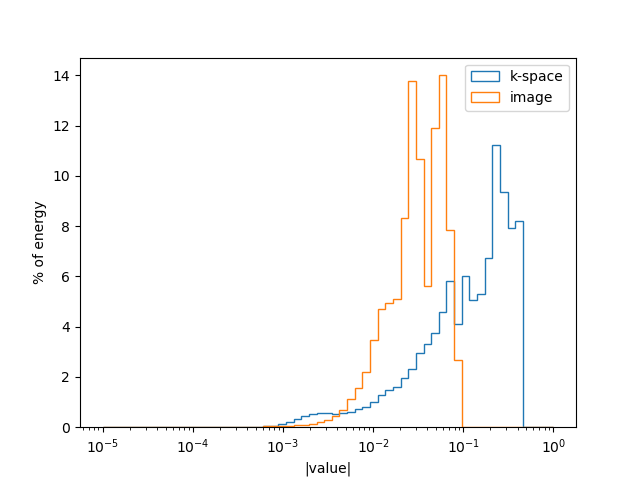

In [2]:
import numpy as np, torch, fastmri, matplotlib.pyplot as plt

k = torch.load("../data/processed/cmrxrecon/test/training_p001_single_coil_full_cine_sax_norm.pt")[:2, 0]
x = fastmri.ifft2c(k)

bins = np.logspace(-5, 0, 60)
for z, label in ((k, "k-space"), (x, "image")):
    m = fastmri.complex_abs(z).numpy().ravel()
    plt.hist(m, bins, weights=m**2 / (m**2).sum() * 100, histtype="step", label=label)

plt.xscale("log")
plt.xlabel("|value|")
plt.ylabel("% of energy")
# plt.ylabel("# of pixels")
plt.legend(); plt.show()


In [2]:
import argparse
from stmr.data.data_utils import complex_abs
def unpack_measurements(y_in: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    # y_in packs the zero-filled measured k-space (channels 0:2) together with the
    # per-frame k-space mask (channels 2:4), so that nmAPG's batch subsetting y[idx]
    # keeps each frame's mask aligned with its measurements (see prepare_inverse_case).
    return y_in[:, :2], y_in[:, 2:]

def complex_l2(val: torch.Tensor, y_in: torch.Tensor, forw: nn.Module, config: argparse.Namespace) -> torch.Tensor:
    kdata, mask = unpack_measurements(y_in)
    diff = mask * forw(val) - kdata
    df = 0.5 * (diff.abs() ** 2).sum((1,2,3))
    return df.reshape(-1)

def reg_on_abs(config: argparse.Namespace, val: torch.Tensor, regularizer: nn.Module) -> torch.Tensor:
    val_abs = complex_abs(val)
    reg = config.lambda_init_recon * regularizer.g(val_abs)
    return reg.reshape(-1)

def reg_without_abs(config: argparse.Namespace, val: torch.Tensor, regularizer: nn.Module) -> torch.Tensor:
    reg = config.lambda_init_recon * regularizer.g(
        val.flatten(0,1).unsqueeze(1)
    ).reshape(val.shape[0], -1).sum(1)
    return reg.reshape(-1)

In [3]:
from stmr.data.data_load import PreparedData
def prep_inputs(data: PreparedData):
    init = data.init
    fixed = data.fixed
    kspace_mask = data.kspace_mask.to(fixed)
    packed_measurements = torch.cat([fixed, kspace_mask.to(fixed)], dim=1)
    forw = data.full_forw
    adj = data.full_adj
    return [init, packed_measurements, forw, adj]

In [6]:
from stmr.data.nmapg import nmAPG
from argparse import Namespace
import logging

from stmr.losses.recon_reg import get_recon_regularizer 
from stmr.data.data_load import prepare_data

config = Namespace(dataset='cmr_P001',
                   slice_number=0,
                   start_frame=0,
                   time_points=2,
                   factor=4,
                   mask='st',
                   device='cuda',
                   kspace_noise_sigma=0,
                   init='adj',
                   recon_scale=5.5,
                   reg_alpha=1.0,
                   lambda_st=1.,
                   recon_epochs=5000,
                   debug=True,
                   tol=1e-4,
                   init_reg_abs=True,
                   regularizer='wcrr',
                   lambda_init_recon=0.02,
                   detach_grads=True,)
prepped_data = prepare_data(config)
recon_init, fixed, forw, adj = prep_inputs(prepped_data)
logging.basicConfig(level=logging.NOTSET)
logger = logging.getLogger('test')
logger.setLevel(logging.NOTSET)
callback = None

In [7]:
regularizer = get_recon_regularizer(config)

def data_fit_fn(val: torch.Tensor, y_in: torch.Tensor) -> torch.Tensor:
    return complex_l2(val, y_in, forw, config)
def reg_eval_fn(val: torch.Tensor) -> torch.Tensor:
    if config.init_reg_abs:
        reg = reg_on_abs(config, val, regularizer)
    else:
        reg = reg_without_abs(config, val, regularizer)
    return reg
def energy_fn(val: torch.Tensor, y_in: torch.Tensor) -> torch.Tensor:
    df = config.lambda_st * data_fit_fn(val, y_in)
    reg = reg_eval_fn(val)
    fun = df + reg
    if config.detach_grads:
        fun = fun.detach()
    return fun.reshape(-1)

def energy_grad_fn(val: torch.Tensor, y_in: torch.Tensor) -> torch.Tensor:
    val_req = val.detach().clone().requires_grad_(True)
    df = config.lambda_st * data_fit_fn(val_req, y_in)
    reg = reg_eval_fn(val_req)
    energy = df + reg
    energy.sum().backward()
    return val_req.grad


def data_grad_fn(val: torch.Tensor, y_in: torch.Tensor) -> torch.Tensor:
    val_req = val.detach().clone().requires_grad_(True)
    df = config.lambda_st * data_fit_fn(val_req, y_in)
    energy = df
    energy.sum().backward()
    return val_req.grad

def reg_grad_fn(val: torch.Tensor, y_in: torch.Tensor) -> torch.Tensor:
    val_req = val.detach().clone().requires_grad_(True)
    reg = reg_eval_fn(val_req)
    energy = reg
    energy.sum().backward()
    return val_req.grad


data_fit = data_fit_fn
reg_eval = reg_eval_fn
energy = energy_fn
energy_grad = energy_grad_fn
energy_and_grad = lambda val, y_in: (energy(val, y_in), energy_grad(val, y_in))
weighted_data_fit = lambda val, y_in: config.lambda_st * data_fit(val, y_in)
L_init = config.lambda_st

print(data_grad_fn(recon_init, fixed).abs().sum(dim=(1,2,3)), reg_grad_fn(recon_init, fixed).abs().sum(dim=(1,2,3)))

print('here')
x, L, i, converged, metrics = nmAPG(x0=recon_init,
                            y=fixed,
                            f=energy,
                            nabla=energy_grad,
                            f_and_nabla=energy_and_grad,
                            max_iter=config.recon_epochs,
                            L_init=L_init,
                            verbose=config.debug,
                            tol=config.tol,
                            data_fit=weighted_data_fit,
                            reg=reg_eval,
                            debug=config.debug,
                            logger=logger,
                            callback=callback,
                            data_grad=data_grad_fn,
                            reg_grad=reg_grad_fn)

INFO:test:Before opt energy 0.0016027966048568487, data fit 5.601563050211533e-13, reg 0.0016027966048568487
INFO:test:Iter 1/5000, energy 0.001593475928530097, data fit 3.466517455308349e-06, reg 0.0015900094294920564, tol tensor([1.0001, 1.0001])
INFO:test:Iter 2/5000, energy 0.0015876960242167115, data fit 3.4188969948445447e-06, reg 0.001584277139045298, tol tensor([0.0006, 0.0006])
INFO:test:Iter 3/5000, energy 0.0015804163413122296, data fit 3.419012045924319e-06, reg 0.0015769973397254944, tol tensor([0.0008, 0.0008])
INFO:test:Iter 4/5000, energy 0.0015717697096988559, data fit 3.414796765355277e-06, reg 0.0015683548990637064, tol tensor([0.0010, 0.0010])


tensor([0.0002, 0.0002], device='cuda:0') tensor([0.6824, 0.6784], device='cuda:0')
here


INFO:test:Iter 5/5000, energy 0.0015618887264281511, data fit 3.4085617244272726e-06, reg 0.0015584802022203803, tol tensor([0.0011, 0.0011])
INFO:test:Iter 6/5000, energy 0.0015509111108258367, data fit 3.3981550586759113e-06, reg 0.0015475129475817084, tol tensor([0.0013, 0.0013])
INFO:test:Iter 7/5000, energy 0.0015389816835522652, data fit 3.3817220810306026e-06, reg 0.0015355999348685145, tol tensor([0.0014, 0.0014])
INFO:test:Iter 8/5000, energy 0.0015262491069734097, data fit 3.3571764106454793e-06, reg 0.0015228919219225645, tol tensor([0.0016, 0.0015])
INFO:test:Iter 9/5000, energy 0.0015128564555197954, data fit 3.3239875847357325e-06, reg 0.001509532448835671, tol tensor([0.0017, 0.0016])
INFO:test:Iter 10/5000, energy 0.0014989397022873163, data fit 3.2814955375215504e-06, reg 0.0014956581871956587, tol tensor([0.0018, 0.0018])
INFO:test:Iter 11/5000, energy 0.0014846279518678784, data fit 3.2301841201842763e-06, reg 0.0014813977759331465, tol tensor([0.0019, 0.0019])
INFO:

In [6]:
data= torch.load('../data/processed/cmrxrecon/test/training_p001_single_coil_full_cine_sax_norm.pt')[:2,0].permute(0, 3, 1, 2)

In [11]:
data.shape, data.abs().mean(), data.abs().min(), data.abs().max()

(torch.Size([2, 2, 204, 512]),
 tensor(0.0017),
 tensor(7.0532e-09),
 tensor(0.4167))

In [9]:
(data**2).sum(dim=(1,2,3))

tensor([8.1857, 8.1956])

In [2]:
res2 = torch.load('../log/decomp/sweep_phi1/h64d2_reg0.01/res.pt', weights_only=False, map_location='cpu')

In [3]:
res2.keys()

dict_keys(['st_dict1', 'st_dict2', 'st_dict_base_large', 'st_dict_base_small', 'abs_phi1', 'abs_phi2', 'abs_phi_base_large', 'abs_phi_base_small', 'coord', 'gt_im', 'mag', 'H', 'W', 'params', 'responsibility'])

In [4]:
res2['responsibility']['resid_split'].keys()

dict_keys(['base', 'r1', 'r2', 'explained_phi1', 'explained_phi2', 'unexplained', 'base_per_interval', 'r1_per_interval', 'r2_per_interval'])

In [5]:
res2['responsibility']['resid_split']['explained_phi1'], res2['responsibility']['resid_split']['explained_phi2'], res2['responsibility']['resid_split']['unexplained']

(0.30123033819539374, 0.2264643674839055, 0.4723052777345066)

In [6]:
base = (np.array(res2['responsibility']['resid_split']['base_per_interval'])*204*512).round(1)
r1 = (np.array(res2['responsibility']['resid_split']['r1_per_interval'])*204*512).round(1)
r2 = (np.array(res2['responsibility']['resid_split']['r2_per_interval'])*204*512).round(1)
phi1_impr = base-r1
phi2_impr = r1-r2

In [29]:
base, r1, r2

(array([11.6, 10.4,  8.3,  6.1,  4.3,  4.5,  3.9,  6.5,  5.9,  4.1,  3.5]),
 array([6.9, 6.9, 5.8, 4.5, 3.3, 3.4, 3. , 4.2, 4.4, 3.3, 2.7]),
 array([3.8, 3.5, 3.4, 3.5, 2.6, 2.6, 2. , 2.5, 3.2, 3.4, 2.3]))

In [8]:
base - r1, r1 - r2

(array([4.7, 3.5, 2.5, 1.6, 1. , 1.1, 0.9, 2.3, 1.5, 0.8, 0.8]),
 array([ 3.1,  3.4,  2.4,  1. ,  0.7,  0.8,  1. ,  1.7,  1.2, -0.1,  0.4]))

In [26]:
tab = [
    ['base diff'] + base.tolist(),
    ['Phi1 diff'] + r1.tolist(),
    ['Phi2 diff'] + r2.tolist(),
    SEPARATING_LINE,
    ['Phi1 improvement'] + phi1_impr.tolist(),
    ['Phi2 improvement'] + phi2_impr.tolist(),
]
print(tabulate(tab, tablefmt='simple'))

----------------  ----  ----  ---  ---  ---  ---  ---  ---  ---  ----  ---
base diff         11.6  10.4  8.3  6.1  4.3  4.5  3.9  6.5  5.9   4.1  3.5
Phi1 diff          6.9   6.9  5.8  4.5  3.3  3.4  3    4.2  4.4   3.3  2.7
Phi2 diff          3.8   3.5  3.4  3.5  2.6  2.6  2    2.5  3.2   3.4  2.3
----------------  ----  ----  ---  ---  ---  ---  ---  ---  ---  ----  ---
Phi1 improvement   4.7   3.5  2.5  1.6  1    1.1  0.9  2.3  1.5   0.8  0.8
Phi2 improvement   3.1   3.4  2.4  1    0.7  0.8  1    1.7  1.2  -0.1  0.4
----------------  ----  ----  ---  ---  ---  ---  ---  ---  ---  ----  ---


In [2]:
r = torch.load('../log/ablation/undersampling_sweep/factor_1/S5/res.pt', weights_only=False, map_location='cpu')

In [3]:
r.keys()

dict_keys(['phi', 'vel', 'coord_tensor', 'st_dict', 'time_stamps', 'epoch', 'moving', 'moved_img_space', 'recon_init', 'config', 'fixed', 'gt_im'])

In [4]:
r['moved_img_space'].shape, r['fixed'].shape, r['gt_im'].shape

(torch.Size([5, 1, 204, 512]),
 torch.Size([6, 2, 204, 512]),
 torch.Size([6, 2, 204, 512]))

In [5]:
(r['fixed']-r['gt_im']).abs().max(), r['fixed'].abs().max(), r['gt_im'].abs().max()

(tensor(0.4336), tensor(0.4399), tensor(0.0879))

In [6]:
moved = r['moved_img_space'].squeeze()
gt_im = fastmri.complex_abs(r['gt_im'].movedim(1,-1))
moved_diff = (moved-gt_im[1:]).abs()
diff = (gt_im[1:]-gt_im[:-1]).abs()
moved.shape, gt_im.shape, moved_diff.shape, diff.shape, diff.max(), moved_diff.max()

(torch.Size([5, 204, 512]),
 torch.Size([6, 204, 512]),
 torch.Size([5, 204, 512]),
 torch.Size([5, 204, 512]),
 tensor(0.0227),
 tensor(0.0168))

In [7]:
diff.sum(dim=(1,2)), moved_diff.sum(dim=(1,2))

(tensor([42.4305, 39.8049, 39.4915, 36.0866, 32.6100]),
 tensor([32.6434, 30.1281, 32.8315, 34.6456, 35.3995]))

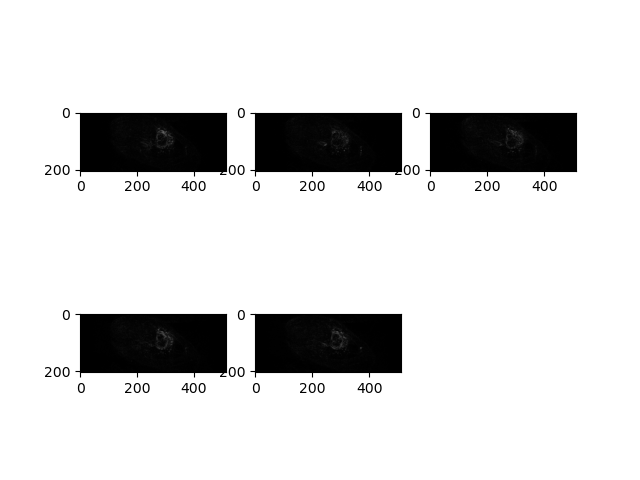

In [8]:
%matplotlib widget
f,a = plt.subplots(2,3)
for x in range(2):
    for y in range(3):
        if 3*x+y < moved_diff.shape[0]:
            a[x,y].imshow(moved_diff[3*x+y], cmap='gray', vmax=diff.max())
        else:
            a[x,y].axis("off")

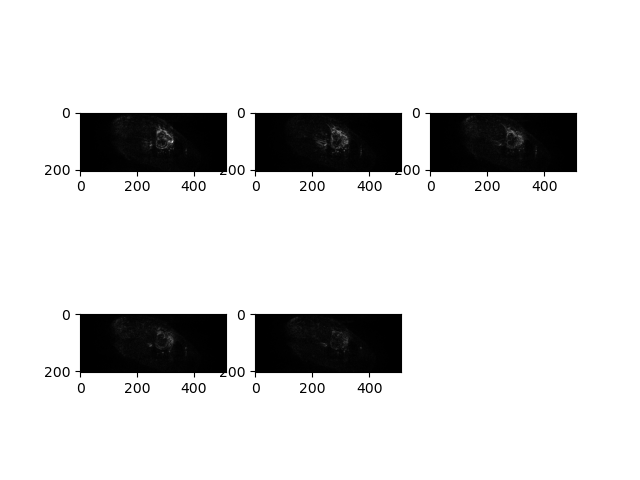

In [56]:
f2,a2 = plt.subplots(2,3)
for x in range(2):
    for y in range(3):
        if 3*x+y < diff.shape[0]:
            a2[x,y].imshow(diff[3*x+y], cmap='gray', vmax=moved_diff.max())
        else:
            a2[x,y].axis("off")

In [12]:
from stmr.data.data_load import prepare_inputs
from logging import Logger
from argparse import Namespace

config = Namespace(
    dataset='cmr_P001',
    slice_number=0,
    start_frame=0,
    time_points=12,
    factor=1,
    mask='st',
    device='cpu',
    kspace_noise_sigma=0.,
    init='gt',
    init_skip=True,
    init_noise_sigma=0.,
)
logger = Logger(name='test')
inp, einp = prepare_inputs(config, logger)

In [3]:
einp.gt_im.shape

torch.Size([12, 2, 204, 512])

In [4]:
from fastmri import complex_abs
gtim = complex_abs(einp.gt_im.movedim(1,-1))

In [5]:
gtim.shape

torch.Size([12, 204, 512])

In [6]:
(gtim[1:]-gtim[:-1]).abs().sum(dim=(1,2))

tensor([42.4305, 39.8049, 39.4915, 36.0866, 32.6100, 32.6194, 29.8492, 32.5183,
        33.6454, 31.4554, 30.6754])

In [7]:
f,a = plt.subplots(2)
a[0].imshow((gtim[0]-gtim[1]).abs(), cmap='gray')
a[1].imshow(gtim[-1], cmap='gray', vmax=0.002)

/home/hansel/miniconda3/envs/reg/lib/python3.12/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


In [10]:
plt.imshow((gtim[0]-gtim[1]).abs(), cmap='gray')

In [8]:
import torch
from stmr.viz.deform import save_gif

gt = torch.load("../log/ablation/20260715_141234/S0/res.pt", map_location="cpu", weights_only=False)["gt_im"]  # [T,2,H,W]
save_gif(gt, "../figs/gt.gif", fps=8)


/home/hansel/miniconda3/envs/reg/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


In [10]:
res = torch.load('log/cmr/soft_con/sim_loss_no_abs/only_rec/noftv3-cmr_gt_test-lr1e-4-rlr1e-5-ilr1e-2-wd0-negJ1e-4-grd0-rl20-lap0-pgr0-hel0-rec1e-7-irec1e-2-sim1-dep3-dim64-tp2-e1000-re50-rs2-euler-ts0.1-groupsiren-st0-sl0-seed0-no-db-apg-no-rm-f1-a1-rec-int0-lit/res.pt', weights_only=False)

In [16]:
init = res['recon_init']
move = res['moving']

inabs = fastmri.complex_abs(init.movedim(1,-1))
moabs = fastmri.complex_abs(move.movedim(1,-1))

In [25]:
inabs.max(), moabs.max(), init.abs().max(), move.abs().max(), init.abs().sum(), inabs.sum()

(tensor(0.0902),
 tensor(0.0900),
 tensor(0.0859),
 tensor(0.0853),
 tensor(1027.7827),
 tensor(812.9919))

In [19]:
lossfn = nn.MSELoss()
loss = lossfn(init, move)
loss

tensor(3.5091e-09)

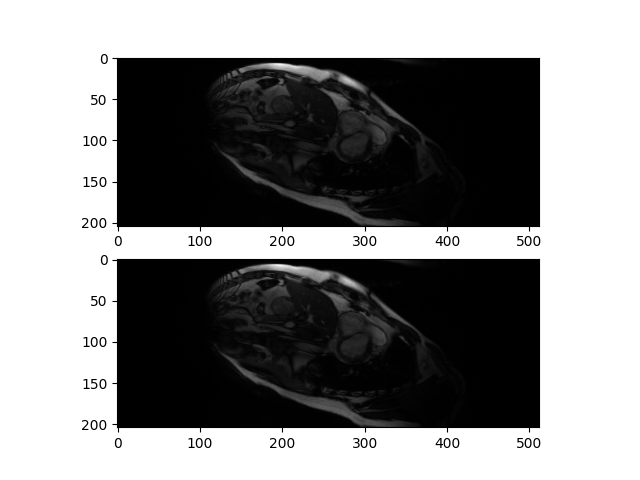

In [15]:
f,a = plt.subplots(2)
a[0].imshow(inabs[0], cmap='gray')
a[1].imshow(moabs[0], cmap='gray')

In [18]:
import copy
from argparse import Namespace

from src.data.data_utils import get_data, get_operators

config = Namespace(
    dataset='cmr_P001',
    slice_number=0,
    start_frame=0,
    time_points=2,
    factor=1,
    mask='st',
    device='cuda',
    recon_epochs=500,
    init_lr=1e-4,
    recon_scale=2,
    reg_alpha=1,
    debug=True,
    lambda_st=1,
    lambda_init_recon=0.,
    loss='mse',
)


raw_kspace_data, gt_kspace_data, kspace_mask = get_data(config)
full_forw, full_adj, forw_subs, forw_subs_adj = get_operators(config, kspace_mask)
smaller_shape = list(raw_kspace_data.shape[:2]) + [-1] + list(raw_kspace_data.shape[3:])
fixed = raw_kspace_data[kspace_mask.expand(raw_kspace_data.shape)].reshape(smaller_shape)
fixed = fixed.to(config.device)

gt_im = full_adj(gt_kspace_data)
gt_im = gt_im.to(config.device)
init = torch.load('data/cmr_p001_init.pt')
init = nn.Parameter(init).to(config.device)

recon, init_metrics = init, None
    
# fixed = fastmri.complex_abs_sq(fixed.movedim(1,-1)).unsqueeze(1)
# fixed = (fixed + 1e-8).sqrt()

recon = recon.detach()
moving = nn.Parameter(recon.clone())
forw = forw_subs

In [19]:
import time

from src.data.data_utils import complex_abs
from src.losses.losses import similarity_loss
from src.losses.recon_reg import get_recon_regularizer

optimizer = torch.optim.Adam([moving], lr=config.init_lr)
# gt = complex_abs(gt_kspace_data).to(config.device)
gt = fixed.to(config.device)
loss_fn = nn.MSELoss(reduction='mean')
regularizer = get_recon_regularizer(config)

metrics = np.zeros((config.recon_epochs+1, 2)) if config.debug else None


best_loss = 1e8
t0 = time.time()
for epoch in range(1, config.recon_epochs + 1):
    optimizer.zero_grad()
    
    # pred = complex_abs(forw(moving))
    # pred = forw(moving)
    # sim_loss = config.lambda_st * loss_fn(pred, gt)
    sim_loss, _ = similarity_loss(config, [moving, None, gt, forw], None)
    sim_loss = sim_loss.mean()
    
    pred = complex_abs(moving)
    reg_loss = config.lambda_init_recon * regularizer.g(pred).mean()
    
    loss_sum = sim_loss + reg_loss
    loss_sum.backward()
    optimizer.step()
    if loss_sum <= best_loss:
        best_recon = moving.detach().clone()
        best_loss = loss_sum.detach().clone()
    if config.debug:
        sim_loss = sim_loss.detach().cpu().clone()
        reg_loss = reg_loss.detach().cpu().clone()
        metrics[epoch] = [sim_loss, reg_loss]
        gt_err_im = (complex_abs(gt_im) - complex_abs(moving)).detach().abs().sum()
        gt_err_ks = (complex_abs(gt) - complex_abs(forw(moving))).detach().abs().sum().cpu()
        im_sp_err = (gt_im - moving).detach().abs().sum()
        ks_sp_err = (gt - forw(moving)).detach().abs().sum().cpu()
        # print(f'Iter {epoch:4}/{config.recon_epochs} energy {sim_loss+reg_loss:.8f}, data fit {sim_loss:.8f}, reg {reg_loss:.8f}, gt err im {gt_err_im:.1f}, gt err ks {gt_err_ks:.1f}')
        print(f'Iter {epoch:4}/{config.recon_epochs} energy {sim_loss+reg_loss:.8f}, data fit {sim_loss:.8f}, reg {reg_loss:.8f}, gt err im {gt_err_im:.1f}, gt err ks {gt_err_ks:.1f}, im sp err {im_sp_err:.1f}, k sp err {ks_sp_err:.1f}')
t1 = time.time()
print(f'Finished initial reconstruction in {t1-t0:.4f} seconds, final loss {sim_loss}')

Iter    1/500 energy 0.00000205, data fit 0.00000205, reg 0.00000000, gt err im 136.4, gt err ks 149.1, im sp err 315.3, k sp err 304.2
Iter    2/500 energy 0.00000198, data fit 0.00000198, reg 0.00000000, gt err im 133.8, gt err ks 148.1, im sp err 307.1, k sp err 298.9
Iter    3/500 energy 0.00000191, data fit 0.00000191, reg 0.00000000, gt err im 131.1, gt err ks 147.0, im sp err 298.9, k sp err 293.6
Iter    4/500 energy 0.00000185, data fit 0.00000185, reg 0.00000000, gt err im 128.5, gt err ks 145.9, im sp err 290.9, k sp err 288.5
Iter    5/500 energy 0.00000178, data fit 0.00000178, reg 0.00000000, gt err im 125.9, gt err ks 144.6, im sp err 283.0, k sp err 283.4
Iter    6/500 energy 0.00000172, data fit 0.00000172, reg 0.00000000, gt err im 123.3, gt err ks 143.2, im sp err 275.1, k sp err 278.5
Iter    7/500 energy 0.00000166, data fit 0.00000166, reg 0.00000000, gt err im 120.7, gt err ks 141.8, im sp err 267.4, k sp err 273.7
Iter    8/500 energy 0.00000160, data fit 0.0000

In [11]:
moving.shape, gt_im.shape

(torch.Size([2, 2, 204, 512]), torch.Size([2, 2, 204, 512]))

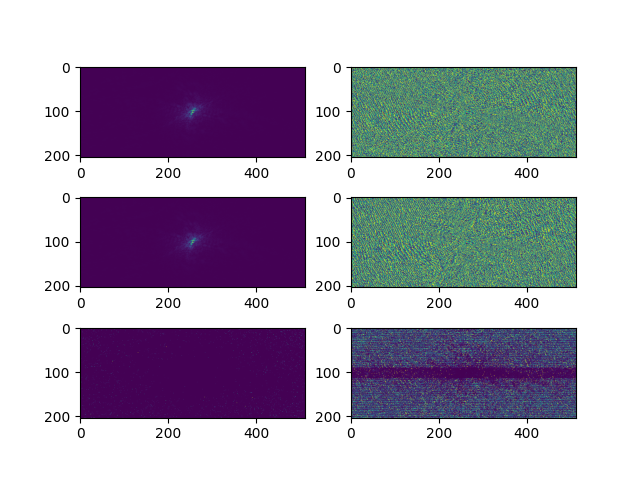

In [12]:
comp_moving = torch.view_as_complex(forw(moving).movedim(1,-1)).detach().cpu()
comp_gt = torch.view_as_complex(gt_kspace_data.movedim(1,-1)).detach().cpu()
f,a = plt.subplots(3,2)
a[0,0].imshow(comp_moving[0].abs())
a[0,1].imshow(comp_moving[0].angle())
a[1,0].imshow(comp_gt[0].abs())
a[1,1].imshow(comp_gt[0].angle())

a[2,0].imshow((comp_gt[0].abs() - comp_moving[0].abs()).abs())
a[2,1].imshow((comp_gt[0].angle() - comp_moving[0].angle()).abs())


In [17]:
import random


def load_shape(name):
    img = Image.open(f'data/syn/{name}.png')
    img = np.array(img, dtype=np.int32)[:,:,0]
    img = 255 - img
    img[img==255] = 3
    img[img==60] = 2
    img[img==128] = 1
    img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(torch.float)
    return img

def get_circles(circles_nr, direction, max_dist=10, img_size=128, seed=42):
    random.seed(seed)
    out = torch.zeros((2, img_size , img_size))
    for i in range(circles_nr):
        overlap = True
        while overlap:
            x, y, x_off, y_off = generate_new_coords(img_size, max_dist)
            if i == 0 or direction != 'same':
                x_offset = x_off
                y_offset = y_off
            x_offset = min(max(x_offset, -x), img_size-33-x)
            y_offset = min(max(y_offset, -y), img_size-33-y)
            overlap = out[:, x:x+32, y:y+32].sum() > 0 or out[:, x+x_offset:x+x_offset+32, y+y_offset:y+y_offset+32].sum() > 0


        # x = random.randint(0, img_size - 32)
        # y = random.randint(0, img_size - 31)
        
        # if i == 0 or direction != 'same':
        #     x_offset = random.randint(max(-max_dist, -x), min(max_dist, img_size-33-x))
        #     y_offset = random.randint(max(-max_dist, -y), min(max_dist, img_size-33-y))
        # else:
        #     x_offset = min(max(x_offset, -x), img_size-33-x)
        #     y_offset = min(max(y_offset, -y), img_size-33-y)
        out[0] = get_circle(x, y, out[0])
        out[1] = get_circle(x + x_offset, y + y_offset, out[1])
    return out

def generate_new_coords(img_size, max_dist):
    x = random.randint(0, img_size - 32)
    y = random.randint(0, img_size - 32)
    x_offset = random.randint(-max_dist, max_dist)
    y_offset = random.randint(-max_dist, max_dist)
    return x, y, x_offset, y_offset

def get_circle(x, y, img):
    # cir = load_shape('cir')[:,:,75:107, 24:56].squeeze()
    # img[x:x+32, y:y+32] = cir
    img[x:x+32, y:y+32] = 1
    return img

In [22]:
cs = []
for i in range(100):
    c = get_circles(5, 'nsame', max_dist=20, img_size=256, seed=i)
    c = torch.stack([c[0], c[1], torch.zeros_like(c[0])], dim=2)
    cs.append(c)

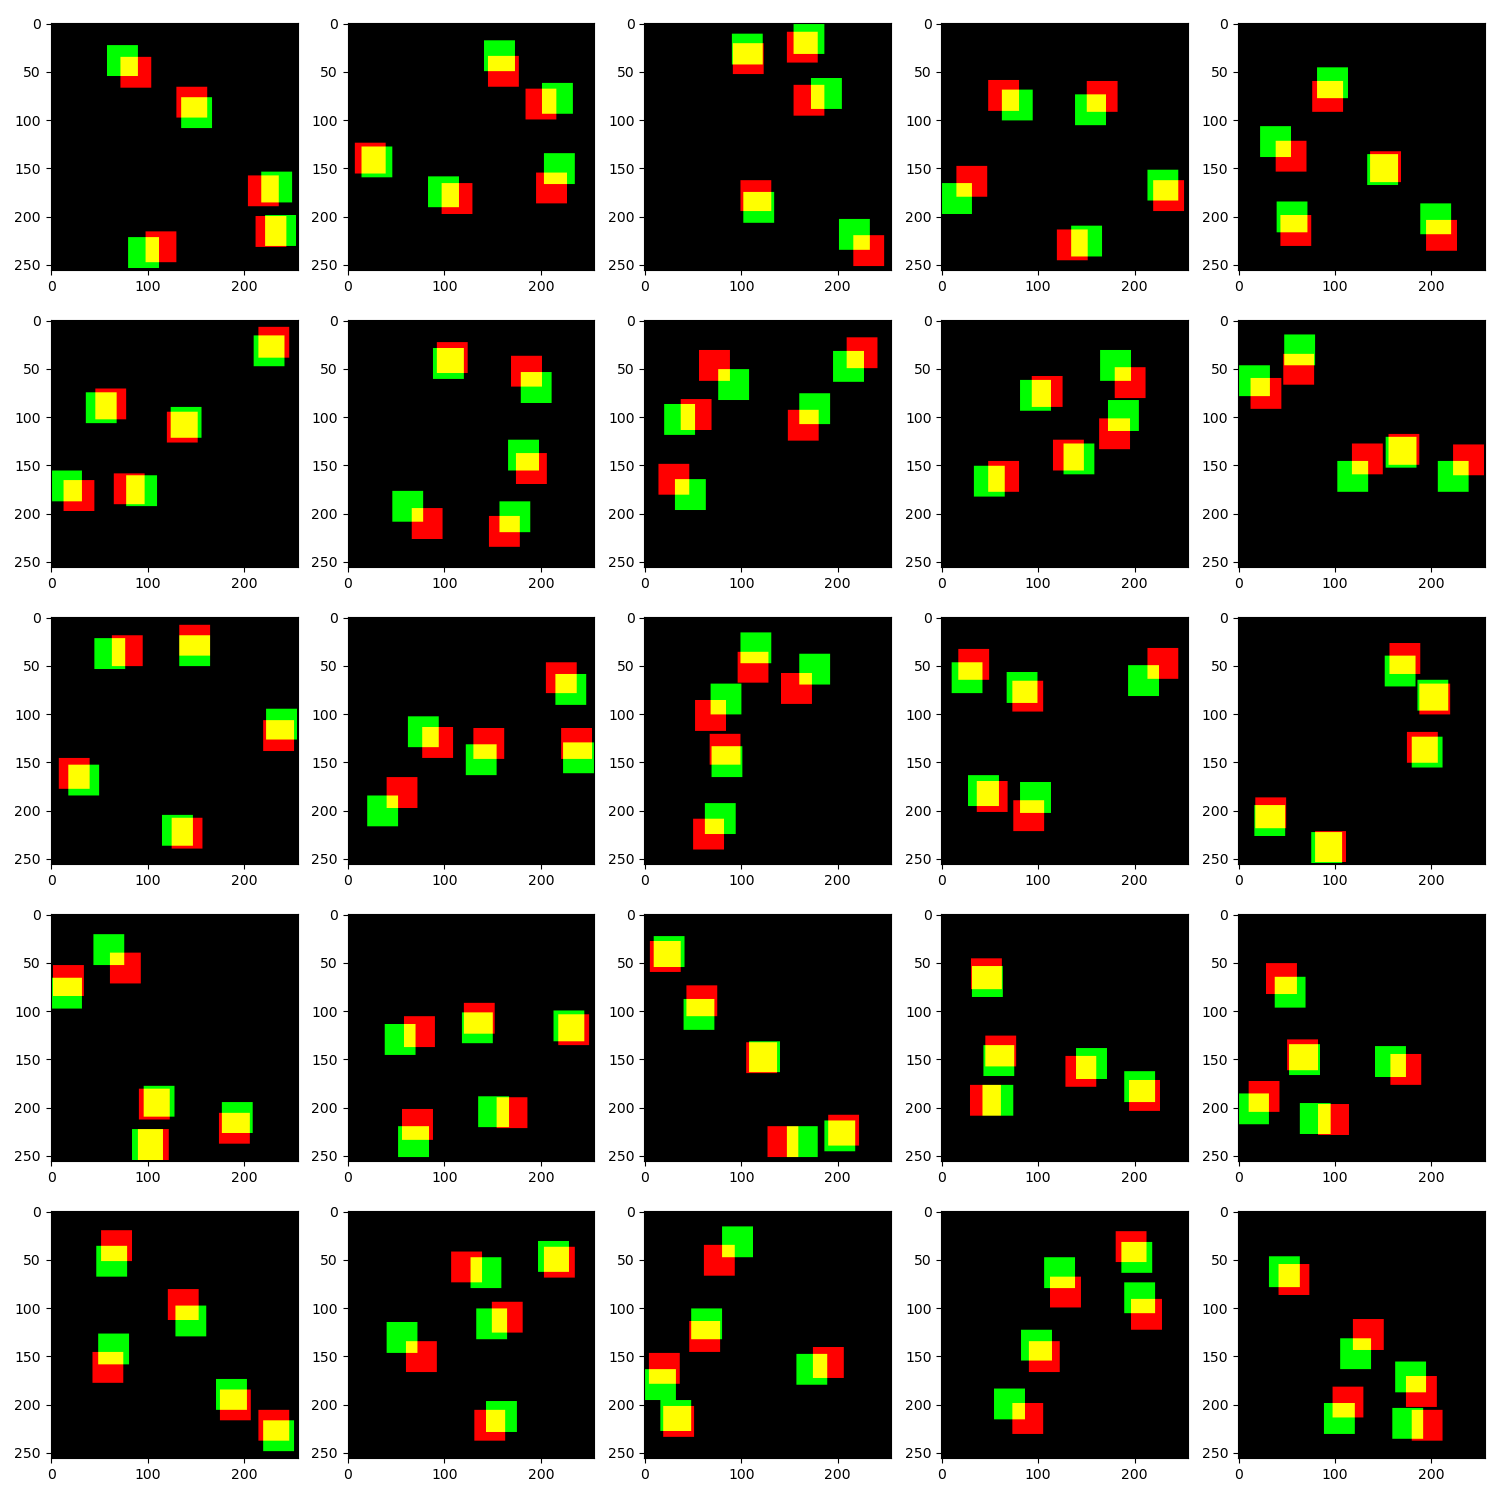

In [23]:
nr = 5
f,a = plt.subplots(nr, nr)
f.set_size_inches(15, 15)
for x in range(nr):
    for y in range(nr):
        a[x,y].imshow(cs[nr*x+y])
f.tight_layout()

In [2]:
from argparse import Namespace

from src.data.fft_utils import FastmriFT, FastmriIFT, FTAndSubsample, ZeroFillAndIFT
from src.data.recon_init import init_using_nmAPG

config = Namespace(
    device='cuda',
    recon_epochs=50,
    lambda_init_recon=1e-2,
    init_lr=1e-2,
    recon_scale=2,
    reg_alpha=1,
    debug=True,
    lambda_st=1,
    sim_use_abs=False,
    reg='learned',
    tol=1e-6,
    detach_grads=True,
    init_loss='l2',
    init_reg_abs=False,
)


gt_kspace_data = torch.load('data/processed/cmrxrecon/test/training_p001_single_coil_full_cine_sax_norm.pt')[:1,0].permute(0, 3, 1, 2)
raw_kspace_data = torch.load('data/processed/cmrxrecon/test/training_p001_single_coil_acc_04_cine_sax_norm.pt')[:1,0].permute(0, 3, 1, 2)
kspace_mask = (raw_kspace_data[:] != 0)

full_forw = FastmriFT()
full_adj = FastmriIFT()
forw_subs = FTAndSubsample(kspace_mask)
forw_subs_adj = ZeroFillAndIFT(kspace_mask)

smaller_shape = list(raw_kspace_data.shape[:2]) + [-1] + list(raw_kspace_data.shape[3:])
fixed = raw_kspace_data[kspace_mask.expand(raw_kspace_data.shape)].reshape(smaller_shape)
fixed = fixed.to(config.device)
# if config.sim_use_abs:
#     fixed = fastmri.complex_abs_sq(fixed.to(config.device).movedim(1,-1)).unsqueeze(1)
#     fixed = (fixed + 1e-8).sqrt()

gt_im = full_adj(gt_kspace_data)
gt_im = gt_im.to(config.device)
recon_init = torch.nn.Parameter(torch.zeros_like(raw_kspace_data, device=config.device), requires_grad=True)
# recon_init = raw_kspace_data[kspace_mask.expand(raw_kspace_data.shape)].reshape(smaller_shape)
# recon_init = forw_subs_adj(recon_init).to(config.device)
# recon_init = torch.nn.Parameter(recon_init, requires_grad=True)
# recon_init = torch.nn.Parameter(full_adj(gt_kspace_data).to(config.device), requires_grad=True)

# recon_init, metrics = init_with_grad_desc(config, recon_init, fixed, forw_subs)
recon_init, metrics = init_using_nmAPG(config, recon_init, fixed, forw_subs, forw_subs_adj, None)
recon_init = recon_init.detach().cpu()

Before opt energy 3.587999105453491, data fit 3.587999105453491, reg 0.0
Iter 1/50, energy 0.022722754627466202, data fit 2.8406693230315083e-13, reg 0.022722754627466202
Iter 2/50, energy 0.021765906363725662, data fit 0.0010509778512641788, reg 0.020714929327368736
Iter 3/50, energy 0.0216822549700737, data fit 0.0008262308547273278, reg 0.02085602469742298
Iter 4/50, energy 0.021620826795697212, data fit 0.0008450399618595839, reg 0.02077578753232956
Iter 5/50, energy 0.021562380716204643, data fit 0.0008316124440170825, reg 0.020730767399072647
Iter 6/50, energy 0.0214963648468256, data fit 0.0008353900047950447, reg 0.020660974085330963
Iter 7/50, energy 0.02142224833369255, data fit 0.0008334208396263421, reg 0.0205888282507658
Iter 8/50, energy 0.021344032138586044, data fit 0.0008370603318326175, reg 0.020506972447037697
Iter 9/50, energy 0.021264147013425827, data fit 0.0008337855688296258, reg 0.020430361852049828
Iter 10/50, energy 0.021184170618653297, data fit 0.0008383976

In [ ]:
from src.vis_utils import create_animation_general

re = recon_init[:,0].abs()
im = recon_init[:,1].abs()
ab = fastmri.complex_abs(recon_init.movedim(1,-1))
co = torch.concat([re, im, ab], dim=1)
html, ani = create_animation_general(co, cmap='gray')
html

In [8]:
from argparse import Namespace

from src.data.data_utils import reconstruct_initial_frame, reconstruct_initial_frame_learned_reg
from src.data.fft_utils import FastmriIFT, FTAndSubsample, ZeroFillAndIFT

config = Namespace(
    dataset='cmr_P001_Acc04',
    slice_number=0,
    start_frame=0,
    time_points=1,
    device='cuda',
    recon_scale=13,
    recon_epochs=20,
    debug=True,
    lambda_st=1,
    lambda_init_recon=10,
    detach_grads=True,
    init_lr=1e-4,
)
patient = config.dataset.split('_')[1][1:]
raw_kspace_data = torch.load(f'data/processed/cmrxrecon/test/training_p{patient}_single_coil_acc_04_cine_sax_norm.pt')[:,config.slice_number].permute(0, 3, 1, 2)
raw_kspace_data = raw_kspace_data[config.start_frame:config.start_frame + config.time_points]
kspace_mask = (raw_kspace_data[:1] != 0)

gt_kspace_data = torch.load(f'data/processed/cmrxrecon/test/training_p{patient}_single_coil_full_cine_sax_norm.pt')[:,config.slice_number].permute(0, 3, 1, 2)
gt_kspace_data = gt_kspace_data[config.start_frame:config.start_frame + config.time_points]

smaller_shape = list(raw_kspace_data.shape[:2]) + [-1] + list(raw_kspace_data.shape[3:])
fixed = raw_kspace_data[kspace_mask.expand(raw_kspace_data.shape)].reshape(smaller_shape)
moving_inr = None
seg_moving = None
seg_fixed = None
inverse_FT = FastmriIFT()
gt_im = inverse_FT(gt_kspace_data)

forward_method = FTAndSubsample(kspace_mask)
inverse_method = ZeroFillAndIFT(kspace_mask)
recon_init = nn.Parameter(torch.zeros_like(raw_kspace_data, device=config.device), requires_grad=True)
recon_init = reconstruct_initial_frame_learned_reg(config=config, recon=recon_init, gt=fixed, forw=forward_method, adj=inverse_method, tol=1e-8)
# recon_init = reconstruct_initial_frame(logger=None, config=config, recon=recon_init, gt=fixed, forw=forward_method)
with torch.no_grad():
    print('gt max min', gt_im.abs().max(), gt_im.min(), 'recon init max min', recon_init.abs().max(), recon_init.min())
    gtabs = fastmri.complex_abs(gt_im.movedim(1, -1))
    reconabs = fastmri.complex_abs(recon_init.detach().cpu().movedim(1, -1))
    print('gt max min', gtabs.max(), gtabs.min(), 'recon init max min', reconabs.max(), reconabs.min())
    print(f'Max abs diff {(gtabs-reconabs).abs().max() / gtabs.max()}, max abs of diff value {(gt_im - recon_init.detach().cpu()).abs().max() / gt_im.abs().max()}')

Before opt energy tensor([3.5880]), data fit tensor([3.5880]), reg tensor([0.])
Iter 0, energy tensor([0.3012]), data fit tensor([2.8407e-13]), reg tensor([0.3012])
Iter 1, energy tensor([0.9672]), data fit tensor([0.2768]), reg tensor([0.6904])
Iter 2, energy tensor([0.3736]), data fit tensor([0.0602]), reg tensor([0.3134])
Iter 3, energy tensor([0.4081]), data fit tensor([0.0558]), reg tensor([0.3523])
Iter 4, energy tensor([0.3055]), data fit tensor([0.0321]), reg tensor([0.2734])
Iter 5, energy tensor([0.2389]), data fit tensor([0.0318]), reg tensor([0.2072])
Iter 6, energy tensor([0.2185]), data fit tensor([0.0299]), reg tensor([0.1886])
Iter 7, energy tensor([0.2196]), data fit tensor([0.0316]), reg tensor([0.1880])
Iter 8, energy tensor([0.2090]), data fit tensor([0.0332]), reg tensor([0.1757])
Iter 9, energy tensor([0.2036]), data fit tensor([0.0339]), reg tensor([0.1696])
Iter 10, energy tensor([0.1989]), data fit tensor([0.0341]), reg tensor([0.1647])
Iter 11, energy tensor([

In [8]:
from src.losses.recon_reg import get_recon_regularizer

loss_fn = nn.MSELoss(reduction='none')
regularizer = get_recon_regularizer(config)
r = config.lambda_init_recon * regularizer.g(recon_init.detach().flatten(0,1).unsqueeze(1)).reshape(recon_init.detach().shape[0], -1).sum(1)
l = loss_fn(forward_method(recon_init.detach().cpu()), fixed)
l2 = loss_fn(forward_method(torch.zeros_like(recon_init).detach().cpu()), fixed)
l.shape, r, l.max()

(torch.Size([1, 2, 69, 512]),
 tensor([0.1460], device='cuda:0'),
 tensor(8.2042e-05))

In [10]:
def show_im(ax, val, vmin, vmax):
    im = ax.imshow(val, vmin=vmin, vmax=vmax, cmap='gray')
    add_cb(im, vmin, vmax)

def add_cb(im, vmin, vmax):
    cb = plt.colorbar(im)
    cb.set_ticks([vmin, vmax])

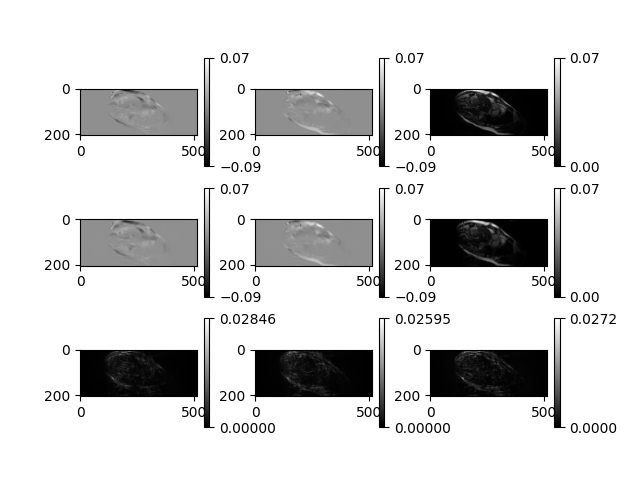

In [11]:
f,a = plt.subplots(3,3)
vmin=-0.09
vmax=0.07
rec = recon_init.detach().cpu()
recabs = fastmri.complex_abs(rec[0].movedim(0,-1))
gtabs = fastmri.complex_abs(gt_im[0].movedim(0,-1))

show_im(a[0,0], gt_im[0,0], vmin, vmax)
show_im(a[0,1], gt_im[0,1], vmin, vmax)
show_im(a[0,2], gtabs, 0, abs(vmax))

show_im(a[1,0], rec[0,0], vmin, vmax)
show_im(a[1,1], rec[0,1], vmin, vmax)
show_im(a[1,2], recabs, 0, abs(vmax))

diff = gt_im[0] - rec[0]
absdiff = (gtabs - recabs)
show_im(a[2,0], diff[0].abs(), 0, diff[0].abs().max())
show_im(a[2,1], diff[1].abs(), 0, diff[1].abs().max())
show_im(a[2,2], absdiff.abs(), 0, absdiff.abs().max())
# a[0,1].imshow(gt_im[0,1], vmin=vmin, vmax=vmax, cmap='gray')
# a[0,2].imshow(fastmri.complex_abs(gt_im[0].movedim(0,-1)), vmin=0, vmax=abs(vmax), cmap='gray')
# # a[3].imshow((torch.angle(torch.view_as_complex(rec[0].movedim(0,-1)))), vmin=-3.15, vmax=3.15, cmap='gray')
# a[1,0].imshow(rec[0,0], vmin=vmin, vmax=vmax, cmap='gray')
# a[1,1].imshow(rec[0,1], vmin=vmin, vmax=vmax, cmap='gray')
# a[1,2].imshow(fastmri.complex_abs(rec[0].movedim(0,-1)), vmin=0, vmax=abs(vmax), cmap='gray')
# a[2,0].imshow((gt_im[0,0]-rec[0,0]).abs(), vmin=0, vmax=abs(vmax), cmap='gray')
# a[2,1].imshow((gt_im[0,0]-rec[0,0]).abs(), vmin=0, vmax=abs(vmax), cmap='gray')
# a[2,2].imshow(fastmri.complex_abs((gt_im[0]-rec[0]).movedim(0,-1)), vmin=0, vmax=abs(vmax), cmap='gray')

In [15]:
fastmri.complex_abs((gt_im[0]-rec[0]).movedim(0,-1)).max(), fastmri.complex_abs(gt_im[0].movedim(0,-1)).max(), fastmri.complex_abs(rec[0].movedim(0,-1)).max()

(tensor(0.0281), tensor(0.0902), tensor(0.0655))

In [16]:
raw_kspace_data.max(), raw_kspace_data.min(), gt_kspace_data.max(), gt_kspace_data.min()

(tensor(0.4399), tensor(-0.3261), tensor(0.4399), tensor(-0.3261))

In [17]:

with torch.no_grad():
    print('fixed max min', fixed.amax(dim=(1,2,3)), fixed.amin(dim=(1,2,3)))
    # print('gt inv max min', inverse_FT(gt_im).max(), inverse_FT(gt_im).min())
    # print('recon init max min', recon_init.max(), recon_init.min())
    print('forw recon', forward_method(recon_init.detach().cpu()).amax(dim=(1,2,3)), forward_method(recon_init.detach().cpu()).amin(dim=(1,2,3)))
    gtabs = fastmri.complex_abs(fixed.movedim(1, -1))
    reconabs = fastmri.complex_abs(recon_init.detach().cpu().detach().movedim(1, -1))
    forwreconabs = fastmri.complex_abs(forward_method(recon_init.detach().cpu()).detach().movedim(1, -1))
    print('gt max min', gtabs.max(), gtabs.min())
    # print('recon init max min', reconabs.max(), reconabs.min())
    print('forw recon max min', forwreconabs.max(), forwreconabs.min())

fixed max min tensor([0.4048, 0.4167, 0.4328, 0.4317, 0.4399]) tensor([-0.3261, -0.3162, -0.2789, -0.2835, -0.2944])
forw recon tensor([0.4048, 0.4167, 0.4328, 0.4317, 0.4399]) tensor([-0.3261, -0.3162, -0.2789, -0.2835, -0.2944])
gt max min tensor(0.4690) tensor(2.8346e-06)
forw recon max min tensor(0.4690) tensor(2.8453e-06)


In [18]:
(gt_kspace_data-inverse_FT(recon_init.detach().cpu()))[kspace_mask].abs().max()

tensor(0.3966)

In [19]:
from src.data.data_utils import FastmriFT

full_forw = FastmriFT()
gt_inv_forw = forward_method(gt_im)
gt_inv_forw.max(), gt_kspace_data.max()

(tensor(0.4399), tensor(0.4399))

In [29]:
rec = recon_init.detach().cpu()
rec_F = inverse_FT(rec)
rec.max(), forward_method(rec_F).max()

(tensor(0.0604), tensor(0.0604))

In [50]:
(gt_im - rec).abs().max(), (full_forw(gt_im) - full_forw(rec)).abs().max(), (forward_method(gt_im) - forward_method(rec)).abs().max(), full_forw(gt_im).abs().max(), full_forw(rec).abs().max()

(tensor(0.0288),
 tensor(0.0851),
 tensor(3.7765e-07),
 tensor(0.4399),
 tensor(0.4399))

In [30]:
rec.shape, fixed.shape

(torch.Size([5, 2, 204, 512]), torch.Size([5, 2, 69, 512]))

In [43]:
for i in range(10):
    x = torch.rand((5,2,204,512))-1
    xF = full_forw(x)
    xf_mask = xF[kspace_mask].reshape(fixed.shape)
    newx = inverse_method(xf_mask)
    xdash = inverse_FT(xF)
    print('fourier', xF.max() - xf_mask.max(), 'image', newx.max() - xdash.max(), xf_mask.max(), xF[~kspace_mask].max())

fourier tensor(0.) image tensor(0.1773) tensor(1.4022) tensor(1.3807)
fourier tensor(0.1198) image tensor(0.2549) tensor(1.2783) tensor(1.3980)
fourier tensor(0.) image tensor(0.1980) tensor(1.3220) tensor(1.3076)
fourier tensor(0.) image tensor(0.2489) tensor(1.2858) tensor(1.2821)
fourier tensor(0.2142) image tensor(0.2048) tensor(1.4136) tensor(1.6278)
fourier tensor(0.0730) image tensor(0.1688) tensor(1.2774) tensor(1.3505)
fourier tensor(0.1503) image tensor(0.2432) tensor(1.3976) tensor(1.5479)
fourier tensor(0.1315) image tensor(0.2182) tensor(1.2754) tensor(1.4069)
fourier tensor(0.1913) image tensor(0.1888) tensor(1.2870) tensor(1.4783)
fourier tensor(0.1994) image tensor(0.1602) tensor(1.3060) tensor(1.5054)


In [20]:
(fixed - forward_method(inverse_method(fixed))).abs().max()

tensor(5.9605e-08)

In [21]:
(gt_im - inverse_method(forward_method(gt_im))).abs().max() / gt_im.abs().max()

tensor(0.3299)

In [22]:
(gt_im - inverse_FT(full_forw(gt_im))).abs().max() / gt_im.abs().max()

tensor(2.5604e-07)

In [23]:
(gt_kspace_data[kspace_mask] - forward_method(inverse_FT(gt_kspace_data)).flatten()).abs().max()

tensor(5.9605e-08)

In [2]:
from src.models.factory import get_func
from src.utils.spatial_utils import generate_coord_tensor
from torchdiffeq import odeint_adjoint as odeint

# TEST ENSEMBLE WITH NEGATIVE TIME

func = get_func('siren', {
    'layers':[2, 64, 64, 2],
    'omega':30,
    'last_init_zero':True
})
func = func.to('cuda')
coord_tensor = generate_coord_tensor(dims=(64, 64), device='cuda')
time_points = torch.linspace(-1, 1, 11, device='cuda')
solver = 'euler'
step_size = 0.1

Original init would be [0.5, 0.015625, 0.015625, 0.5]
Mean of weight of last layer 0.0016


In [5]:
coord_tensor.shape

torch.Size([4096, 2])

In [12]:
class TestFunc(nn.Module):
    def __init__(self):
        super().__init__()
        self.coord_tensor = generate_coord_tensor(dims=(64, 64), device='cuda')

    def forward(self, t, x):
        c = self.coord_tensor
        if t > 0:
            c[:,0] = c[:,0] + 0.1
        else:
            c[:,1] = c[:,1] + 0.1
        return c

In [13]:
tfunc = TestFunc()
abs_phi = odeint(tfunc, coord_tensor, time_points, method=solver, options={'step_size':step_size})

In [14]:
abs_phi.shape

torch.Size([11, 4096, 2])

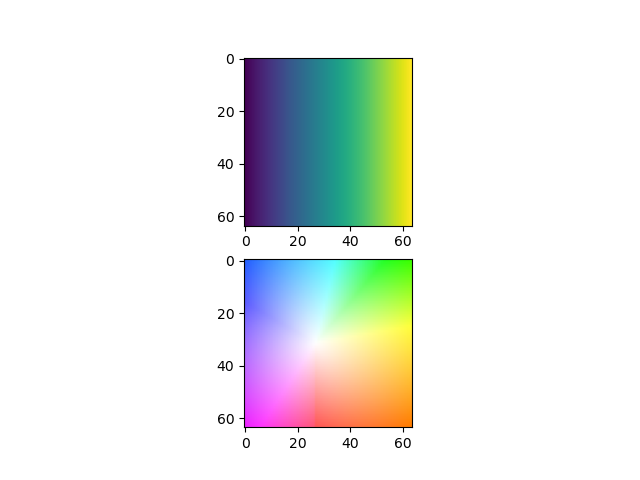

In [27]:
from flow_vis import flow_to_color

f,a = plt.subplots(2)
rel_phi = abs_phi-coord_tensor
a[0].imshow(rel_phi[-1,:,1].reshape(64, 64).cpu())
a[1].imshow(flow_to_color(rel_phi[1,:].reshape(64, 64, 2).cpu().numpy()))

In [19]:
abs_phi[1,:,1]

tensor([-1.1700, -1.1319, -1.0938,  ...,  1.1538,  1.1919,  1.2300],
       device='cuda:0')

In [4]:
abs_phi.shape

torch.Size([11, 4096, 2])

In [22]:
from src.data.data_load import FastmriIFT

raw_kspace_data = torch.load('data/processed/cmrxrecon/test/training_p001_single_coil_full_cine_sax.pt')[:,0].permute(0, 3, 1, 2)
raw_kspace_data = raw_kspace_data[[0,6]]
print(raw_kspace_data.min(), raw_kspace_data.max(), raw_kspace_data.mean())
im_range = raw_kspace_data.max() - raw_kspace_data.min()
mid_point = (raw_kspace_data.max() + raw_kspace_data.min()) / 2
new_raw_kspace_data = (raw_kspace_data) / im_range
inverse_ft = FastmriIFT()
gt_im = inverse_ft(raw_kspace_data)
ngt_im = inverse_ft(new_raw_kspace_data)
new_raw_kspace_data.min(), new_raw_kspace_data.max(), new_raw_kspace_data.mean()

tensor(-0.0104) tensor(0.0132) tensor(4.4562e-07)


(tensor(-0.4409), tensor(0.5591), tensor(1.8937e-05))

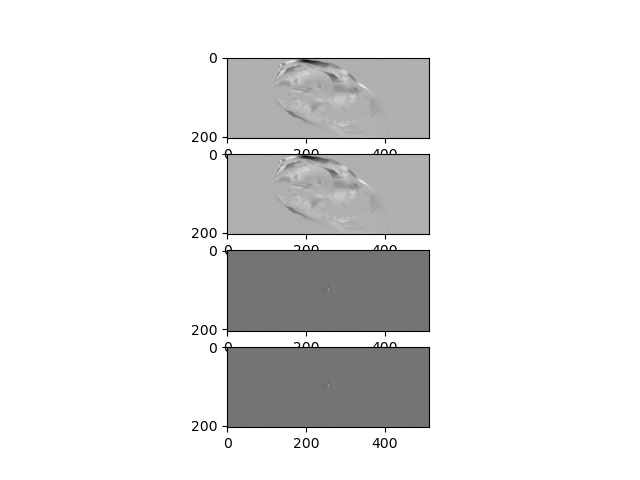

In [21]:
f2,a2=plt.subplots(4)
a2[0].imshow(gt_im[0,0], cmap='gray')
a2[1].imshow(ngt_im[0,0], cmap='gray')
a2[2].imshow(raw_kspace_data[0,0], cmap='gray')
a2[3].imshow(new_raw_kspace_data[0,0], cmap='gray')


In [6]:
res = torch.load('log/cmr/checking_motion/full_siren_init_zeroreally_2imgs_noFT-cmr_motiontest3-lr1e-4-rlr1e-5-ilr1e-2-wd0-negJ0-grd0-lap0-pgr0-hel0-rec1e-9-irec1e-4-sim1-dep3-dim64-tp2-e500-re500-rs1e1-euler-ts0.1-sirenensemble-findif-aggrid-grid-rtol1e-6-atol1e-8-no-nrep-st0-sl0-seed0-db-apg/res.pt', weights_only=False, map_location='cpu')

In [7]:
res.keys()

dict_keys(['phi', 'vel', 'coord_tensor', 'moved_imgs', 'st_dict', 'time_stamps', 'epoch', 'moving', 'moved_img_space', 'config'])

In [8]:
res['moved_imgs'].shape

torch.Size([2, 2, 204, 512])

In [9]:
moved_abs = fastmri.complex_abs(res['moved_imgs'].movedim(1,-1))

In [2]:
from argparse import Namespace
from logging import Logger

from src.data.data_load import prepare_inverse_case

logger = Logger('test')
config = Namespace(dataset='cmr_motiontest3', slice_number=0, start_frame=0, time_points=2)

recon_init, moving_inr, fixed, gt_im, seg_moving, seg_fixed, forward_method, inverse_method = prepare_inverse_case(logger, config)
init_abs = fastmri.complex_abs(recon_init.detach().cpu().movedim(1,-1))
fixed_abs = fastmri.complex_abs(fixed.detach().cpu().movedim(1,-1))
gt_abs = fastmri.complex_abs(gt_im.detach().cpu().movedim(1,-1))
fixed_im_abs = fastmri.complex_abs(inverse_method(fixed).detach().cpu().movedim(1,-1))

In [12]:
gt_abs.min(), gt_abs.max(), gt_abs.mean()

(tensor(2.1383e-06), tensor(0.0029), tensor(0.0001))

In [3]:
recon_init.shape, fixed.shape, gt_im.shape, forward_method, inverse_method, init_abs.shape, fixed_abs.shape, gt_abs.shape

(torch.Size([2, 2, 204, 512]),
 torch.Size([2, 2, 204, 512]),
 torch.Size([2, 2, 204, 512]),
 Identity(),
 Identity(),
 torch.Size([2, 204, 512]),
 torch.Size([2, 204, 512]),
 torch.Size([2, 204, 512]))

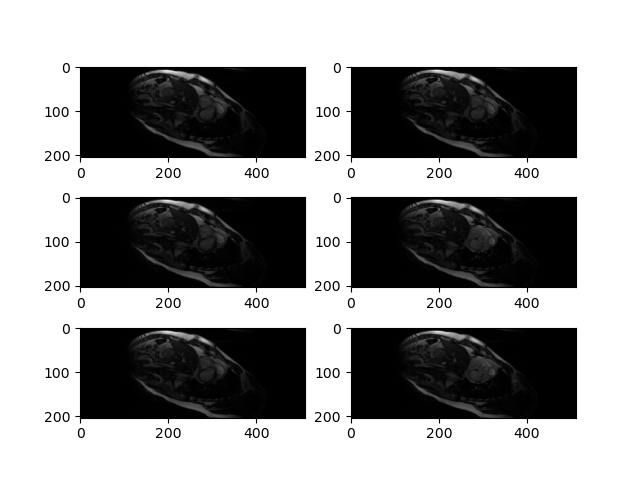

In [11]:
f,a= plt.subplots(3,2)
for t in range(2):
    for i, im in enumerate([moved_abs, fixed_im_abs, gt_abs]):
        a[i,t].imshow(im[t], cmap='gray')

In [2]:
from argparse import Namespace

from src.data.data_utils import FastmriIFT, FTAndSubsample, ZeroFillAndIFT

inverse_FT = FastmriIFT()
patient = '001'
device = 'cuda'
config = Namespace(recon_lr=1e-5, device=device, recon_epochs=500, lambda_st=1, lambda_recon=1e-9)
logger = None

/home/hansel/developer/space_time_reg/src/siren/training.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
gt_kspace_data = torch.load(f'data/processed/cmrxrecon/test/training_p{patient}_single_coil_full_cine_sax.pt')[:,0].permute(0, 3, 1, 2)
gt_kspace_data = gt_kspace_data[:5]
gt_im = inverse_FT(gt_kspace_data)

In [4]:
# raw_kspace_data = torch.load(f'data/processed/cmrxrecon/test/training_p{patient}_single_coil_acc_04_cine_sax.pt')[:,0].permute(0, 3, 1, 2)
# raw_kspace_data = raw_kspace_data[:5]
# kspace_mask = (raw_kspace_data[:1] != 0)
# smaller_shape = list(raw_kspace_data.shape[:2]) + [-1] + list(raw_kspace_data.shape[3:])
# fixed = raw_kspace_data[kspace_mask.expand(raw_kspace_data.shape)].reshape(smaller_shape)

# forward_method = FTAndSubsample(kspace_mask)
# inverse_method = ZeroFillAndIFT(kspace_mask)
# recon_init = nn.Parameter(torch.zeros_like(raw_kspace_data, device=device), requires_grad=True)
# recon_init = reconstruct_initial_frame(logger=logger, config=config, recon=recon_init, gt=fixed, forw=forward_method)
recon_init = torch.load('data/test/recon_init_test.pt')

In [5]:
# torch.save(recon_init.detach().cpu(), 'data/test/recon_init_test.pt')

In [6]:
res = torch.load('log/cmr/pdf_test/first_test_slice0-cmr_P001_Acc04-lr1e-4-rlr1e-5-wd0-negJ0-grd0-lap0-pgr0-hel0-rec1e-9-sim1-dep3-dim64-tp5-e500-re500-euler-ts0.1-sirenensemble-findif-aggrid-grid-rtol1e-6-atol1e-8-no-nrep-st0-sl0-seed0-no-db/res.pt', weights_only=False, map_location='cpu')
final = res['moved_img_space']
phi = res['phi']
vel = res['vel']
coords = res['coord_tensor']

In [7]:
res.keys()

dict_keys(['phi', 'vel', 'coord_tensor', 'moved_imgs', 'st_dict', 'time_stamps', 'epoch', 'moving', 'moved_img_space', 'config'])

In [8]:
recon_init.shape, phi.shape, vel.shape, coords.shape, gt_im.shape, final.shape

(torch.Size([5, 2, 204, 512]),
 torch.Size([5, 104448, 2]),
 torch.Size([5, 104448, 2]),
 torch.Size([104448, 2]),
 torch.Size([5, 2, 204, 512]),
 torch.Size([5, 2, 204, 512]))

In [9]:
from argparse import Namespace

config = Namespace(log_path='/home/hansel/developer/space_time_reg/log/cmr/pdf_test/test')
gt = gt_im[:5]
init = recon_init[:5]
final = final
abs_phi = phi.reshape(5, 204, 512, 2)
rel_vel = vel.reshape(5, 204, 512, 2)

In [10]:
from src.metrics.visualisation import prep_vis_summary_pdf

prep_vis_summary_pdf(config, gt, init, final, abs_phi, rel_vel)

In [2]:
from src.models.siren import SirenEnsemble

t_series = torch.linspace(0, 1, 10)
siren_ens = SirenEnsemble(t_series, layers=[2, 64, 64, 2])

In [3]:
t_series

tensor([0.0000, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889,
        1.0000])

In [4]:
siren_ens.get_model_index(1.)

8

In [ ]:
gt = torch.load('data/processed/cmrxrecon/test/training_p001_single_coil_full_cine_sax.pt')[:2,0].permute(0,3,1,2)
short_res = torch.load('log/cmr_longtest/no_recon_grad_full001_short-cmr_full2-lr1e-5-rlr1e-5-negJ0-grd0-lap0-pgr0-hel0-rec1e-9-sim1-dep3-dim64-tp2-e5-re500-euler-ts0.1-siren-findif-aggrid-grid-rtol1e-6-atol1e-8-no-nrep-st0-seed0-db/res.pt', map_location='cpu', weights_only=False)
long_res = torch.load('log/cmr_longtest/no_recon_grad_full001-cmr_full2-lr1e-5-rlr1e-5-negJ0-grd0-lap0-pgr0-hel0-rec1e-9-sim1-dep3-dim64-tp2-e500-re500-euler-ts0.1-siren-findif-aggrid-grid-rtol1e-6-atol1e-8-no-nrep-st0-seed0-db/res.pt', map_location='cpu', weights_only=False)

In [ ]:
short_res.keys(), long_res.keys()

In [ ]:
gt.shape

In [ ]:
gt_im = fastmri.ifft2c(gt.movedim(1,-1)).movedim(-1,1)
lres = long_res['moved_img_space']
sres = short_res['moved_img_space']
lres.shape, gt_im.shape

In [ ]:
lres.max(), sres.max(), gt_im.max(), (lres-gt_im).max(), (sres-gt_im).max(), lres.min(), sres.min(), gt_im.min(), (lres-gt_im).min(), (sres-gt_im).min()

In [ ]:
f,a = plt.subplots(5,4)
for i, ims in enumerate([lres, sres, gt_im, (lres-gt_im), (sres-gt_im)]):
    for t in range(2):
        for chan in range(2):
            a[i, t*2+chan].imshow(ims[t, chan], cmap="gray", vmax=0.0015, vmin=-0.0015)
            a[i, t*2+chan].set_title(f'image {i}, time {t}, channel {chan}')
            a[i, t*2+chan].axis("off")

In [ ]:
from src.vis_utils import load_shape

rec = load_shape('rec').squeeze()[20:40, 24:60]
cir = load_shape('cir').squeeze()[75:107, 24:56]
re1 = torch.zeros((128, 128))
re2 = torch.zeros((128, 128))
im1 = torch.zeros((128, 128))
im2 = torch.zeros((128, 128))
re1[32:64,32:64] = cir
re2[48:80,32:64] = cir
im1[64:96,64:96] = 1
im2[48:80,64:96] = 1
comb = torch.zeros((2,2,128,128))
comb[0,0] = re1
comb[1,0] = re2
comb[0,1] = im1
comb[1,1] = im2
from fastmri import ifft2c

fcomb = ifft2c(comb.movedim(1, -1)).movedim(-1,1)
fcomb.shape

re12 = torch.zeros((128, 128))
re22 = torch.zeros((128, 128))
im12 = torch.zeros((128, 128))
im22 = torch.zeros((128, 128))
re12[32:64,32:64] = cir
re22[48:80,32:64] = cir
im12[64:96,64:96] = 0
im22[48:80,64:96] = 0
comb2 = torch.zeros((2,2,128,128))
comb2[0,0] = re12
comb2[1,0] = re22
comb2[0,1] = im12
comb2[1,1] = im22
from fastmri import ifft2c

fcomb2 = ifft2c(comb2.movedim(1, -1)).movedim(-1,1)
fcomb2.shape


re13 = torch.zeros((128, 128))
re23 = torch.zeros((128, 128))
im13 = torch.zeros((128, 128))
im23 = torch.zeros((128, 128))
re13[32:64,32:64] = 0
re23[48:80,32:64] = 0
im13[64:96,64:96] = 1
im23[48:80,64:96] = 1
comb3 = torch.zeros((2,2,128,128))
comb3[0,0] = re13
comb3[1,0] = re23
comb3[0,1] = im13
comb3[1,1] = im23
from fastmri import ifft2c

fcomb3 = ifft2c(comb3.movedim(1, -1)).movedim(-1,1)
fcomb3.shape

In [ ]:
from argparse import Namespace

from src.data.data_utils import FastmriFT, FastmriIFT, FTAndSubsample, ZeroFillAndIFT

config = Namespace(device='cuda', recon_lr=1e-5, recon_epochs=500, lambda_st=1, lambda_recon=5e-9)
ksapce = torch.load('data/processed/cmrxrecon/test/training_p001_single_coil_acc_04_cine_sax.pt')[:1,0].permute(0,3,1,2)
ksapcemask = (ksapce != 0)
forw = FTAndSubsample(ksapcemask)
back = ZeroFillAndIFT(ksapcemask)

gt = ksapce[ksapcemask].reshape(1, 2, -1, 512)
recon_init = nn.Parameter(torch.zeros_like(ksapce, device=config.device), requires_grad=True)

In [ ]:
ksapce.shape

In [ ]:
recon = reconstruct_initial_frame(logger=None, config=config, recon=recon_init, gt=gt, forw=forw)
recon = recon.detach().cpu()
gt = gt.detach().cpu()

In [ ]:
ran = recon.unsqueeze(0)
fowrran = forw(ran)
bfran = back(fowrran)
(bfran - ran).abs().max(), bfran.abs().max(), ran.abs().max()

In [ ]:
(fowrran.squeeze(0)-gt.squeeze(0)).norm(dim=0).max()

In [ ]:
f1,a1 = plt.subplots(2,3)
a1[0,0].imshow(recon.norm(dim=0))
a1[0,1].imshow(bfran.squeeze(0).norm(dim=0))
a1[0,2].imshow((bfran.squeeze(0)-recon).norm(dim=0))
a1[1,0].imshow(gt.squeeze().norm(dim=0))
a1[1,1].imshow(fowrran.squeeze(0).norm(dim=0))
a1[1,2].imshow((fowrran.squeeze(0)-gt.squeeze(0)).norm(dim=0))

In [ ]:
from learned_regularizers.priors import WCRR, ParameterLearningWrapper

reg = WCRR(sigma=0.1, weak_convexity=0.0).to('cuda')
regu = ParameterLearningWrapper(reg, device='cuda')
weights = torch.load('learned_regularizers/weights/bilevel_CT/CRR_bilevel_JFB_for_CT.pt', map_location='cuda')
regu.load_state_dict(weights)
regu.eval()
for p in regu.parameters():
    p.requires_grad_(False)

In [ ]:
x = torch.rand((2,1,204,512), device='cuda').float()

In [ ]:
out = regu.g(x)

In [ ]:
out.shape

In [ ]:
im1 = torch.from_numpy(nib.load('data/oasis_example/OAS1_0001_MR1/brain.nii.gz').get_fdata())
seg1 = torch.from_numpy(nib.load('data/oasis_example/OAS1_0001_MR1/brain_aseg.nii.gz').get_fdata())
im2 = torch.from_numpy(nib.load('data/oasis_example/OAS1_0002_MR1/brain.nii.gz').get_fdata())
seg2 = torch.from_numpy(nib.load('data/oasis_example/OAS1_0002_MR1/brain_aseg.nii.gz').get_fdata())

res1 = torch.load('log/oasis_ngf/nodeo_loss_tslow-oasis_examplev1-lr1e-5-negJ0-smt0-grd0-lap0-pgr0-hel0-sim1-dep3-dim256-tp2-e2000-euler-ts0.1-siren-findif-aggrid-grid-rtol1e-6-atol1e-8-no-nrep-st0-seed0-db/res.pt', weights_only=False)
res2 = torch.load('log/oasis_ngf/nodeo_loss_tslow-oasis_examplev1-lr1e-4-negJ0-smt0-grd0-lap0-pgr0-hel0-sim1-dep3-dim256-tp2-e2000-euler-ts0.1-siren-findif-aggrid-grid-rtol1e-6-atol1e-8-no-nrep-st0-seed0-db/res.pt', weights_only=False)

In [ ]:
def calc_dice(array1, array2, labels):
    """
    Computes the dice overlap between two arrays for a given set of integer labels.
    """
    dicem = np.zeros(len(labels))
    for idx, label in enumerate(labels):
        top = 2 * np.sum(np.logical_and(array1 == label, array2 == label))
        bottom = np.sum(array1 == label) + np.sum(array2 == label)
        bottom = np.maximum(bottom, np.finfo(float).eps)  # add epsilon
        dicem[idx] = top / bottom
    return dicem

In [ ]:
from src.utils import apply_grid_sample


def from_res_to_everything(res):
    abs_phi = res['phi']
    rel_phi = res['phi'] - res['coord_tensor']
    input_seg = seg1.unsqueeze(0).expand(abs_phi.shape[0], 1, *seg1.shape).float()
    pred = apply_grid_sample(input_seg, abs_phi, mode='nearest')
    input_mri = im1.unsqueeze(0).expand(abs_phi.shape[0], 1, *im1.shape).float()
    pred_img = apply_grid_sample(input_mri, abs_phi)
    label = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 24, 28, 41, 42, 43, 46, 47, 49, 50, 51, 52, 53, 54, 60]
    dice = calc_dice(seg2.numpy(), pred[-1].numpy(), labels=label)
    return pred, pred_img, dice

In [ ]:
pred_seg1, pred_img1, dice1 = from_res_to_everything(res1)
pred_seg2, pred_img2, dice2 = from_res_to_everything(res2)

In [ ]:
import matplotlib.colors as mcolors

colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#393b79", "#637939", "#8c6d31", "#843c39", "#7b4173",
    "#3182bd", "#31a354", "#756bb1", "#636363", "#969696",
    "#9c9ede", "#cedb9c", "#e7ba52", "#e7969c", "#de9ed6",
    "#9ecae1", "#a1d99b", "#dadaeb"
]
labels = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 24, 28, 41, 42, 43, 46, 47, 49, 50, 51, 52, 53, 54, 60]
col_list = ["#000000"]*60
for i in range(60):
    col_list[i] = colors[labels.index(i)] if i in labels else "#000000"
our_cmap = mcolors.ListedColormap(col_list)

In [ ]:
from src.vis_utils import create_animation_general

lab = 2
pred_to_show1 = (pred_seg1 * (pred_seg1 == lab)) > 0
pred_to_show2 = (pred_seg2 * (pred_seg2 == lab)) > 0
seg_to_show = (seg2 * (seg2 == lab)) > 0
concat_seg = torch.concat([seg_to_show, pred_to_show1[1,0], pred_to_show2[1,0]], dim=-3).permute(1,2,0).flip(1)
concat_seg = concat_seg.clip(min=0, max=4)
stacked_seg1 = torch.stack([seg_to_show, pred_to_show1[1,0], torch.zeros_like(seg_to_show)], dim=0).permute(2,3,1,0).flip(0).float()
stacked_seg1 = stacked_seg1.clip(min=0, max=4)
stacked_seg2 = torch.stack([seg_to_show, torch.zeros_like(seg_to_show), pred_to_show2[1,0]], dim=0).permute(2,3,1,0).flip(0).float()
stacked_seg2 = stacked_seg2.clip(min=0, max=4)
html, ani = create_animation_general(concat_seg)
html_stack1, _ = create_animation_general(stacked_seg1)
html_stack2, _ = create_animation_general(stacked_seg2)

In [ ]:
cmap = plt.cm.get_cmap('hsv', 60)
stacked_seg = torch.concat([seg1, pred_seg2[1,0], seg2], dim=-3)
html, ani = create_animation_general(stacked_seg.permute(1,2,0).flip(1), cmap=our_cmap)
stacked_im = torch.concat([im1, pred_img2[1,0], im2], dim=-3)
html_im, ani_im = create_animation_general(stacked_im.permute(1,2,0).flip(1))
comb_im = torch.stack([im2, torch.zeros_like(im2), pred_img2[1,0]], dim=0)
html_im_comb, ani_im_comb = create_animation_general(comb_im.permute(2,3,1,0).flip(1).float())

In [ ]:
dataset = 'rot_slow2'
fixed = imgs = torch.from_numpy(np.load(f'data/syn/{dataset}/{dataset}.npy').transpose((2, 0, 1)))[:5].unsqueeze(1)
res = torch.load('log/ngf_fix/rk4_v7_rot_slow2_lr1e-5_negJ1e3_smt10_grd1_dep2_dim64_tp_5_e100_rk4_ts1/res.pt')
res_moved = res['moved_imgs'].unsqueeze(1)

In [ ]:
from src.siren import modules
from src.utils import generate_coord_tensor

img_shape = (168, 168)
lr = 1e-4
num_epochs = 10000
layers = [2, 32, 32, 2]
device = 'cuda'
time_points = 5
dataset = 'rot_slow2'

nrep_st_dict = torch.load(f'data/syn/{dataset}/{dataset}_nrep_st_dicts.pt')[0]
model = modules.SingleBVPNet(type='sine', mode='mlp', sidelength=img_shape, device=device)
model.load_state_dict(nrep_st_dict)
model.eval()
time_0_nrep = model.net.to(device)

coord_tensor = generate_coord_tensor(img_shape, device)
coord_cpu = generate_coord_tensor(img_shape, 'cpu')
coord_img_cpu = coord_cpu.view(img_shape[0], img_shape[1], 2)
const_t = torch.tensor(0, device=device)

rel_grid = np.zeros((5, img_shape[0], img_shape[1], 2))

In [ ]:
import math

from flow_vis import flow_to_color

# angles = math.pi*np.linspace(0, 0, time_points)
# xs = np.linspace(0, 0.5, time_points)
# ys = np.linspace(0, 0, time_points)
angles = math.pi*np.array([0., 0., 0.25, -0.25, 0.])
xs = np.array([-0.2, 0., 0., 0., 0.])
ys = np.array([0., -0.2, 0., 0., 0.])

i = 1
for i in range(5):
    phi = angles[i]
    rot_m = torch.tensor([[math.cos(phi), -math.sin(phi)], [math.sin(phi), math.cos(phi)]])
    tr = torch.tensor([[xs[i]], [ys[i]]])
    theta = torch.concat([rot_m, tr], dim=-1).unsqueeze(0).to(torch.float)
    aff_gird = torch.nn.functional.affine_grid(theta, size=torch.Size([1, 1, img_shape[0], img_shape[1]]), align_corners=False).squeeze().numpy()
    aff_gird = np.stack([aff_gird[:,:,1], aff_gird[:,:,0]], axis=2)
    rel_grid[i ] = (aff_gird - coord_img_cpu.numpy())

grid_color = torch.from_numpy(flow_to_color(aff_gird, convert_to_bgr=False))

In [ ]:
from src.networks import Siren, SirenT
from torch.optim import Adam

model = SirenT(layers=layers)
model.to(device)
optim = Adam(params=model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()
gt = torch.from_numpy(rel_grid).view(-1, 2).to(device)

In [ ]:
time_step = 0.1
# solver = 'rk4'
time_series = torch.arange(time_points, device=device) * time_step

In [ ]:
min_loss = 1e10
best_epoch = 0
for epoch in range(num_epochs):
    preds = []
    for t in time_series:
        preds.append(model(t, coord_tensor))
    pred = torch.concat(preds)
    loss = loss_fn(pred, gt.float())
    optim.zero_grad()
    loss.backward()
    optim.step()
    if loss < min_loss:
        min_loss = loss
        best_st_dict = model.state_dict()
        best_epoch = epoch
    if (epoch + 1) % 2000 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, curr loss {loss}, best loss {min_loss} from epoch {best_epoch}')
best_model = copy.deepcopy(model)
best_model.load_state_dict(best_st_dict)

In [ ]:
from torchdiffeq import odeint_adjoint as odeint

phi_rk = odeint(best_model, coord_tensor, time_series.float(), method='rk4')
phi_eu = odeint(best_model, coord_tensor, time_series.float(), method='euler')

In [ ]:
model_input = coord_tensor
outs = []
for ti in time_series[:-1]:
    model_out = best_model(ti, model_input)
    model_input = model_out * time_step + model_input
    outs.append(model_input)

In [ ]:
from src.networks import SirenT
from src.utils import generate_coord_tensor
from torch.optim import Adam

n_img_shape = (168, 168)
n_imgs = np.load('data/syn/rot_slow2/rot_slow2.npy')

num_epochs = 2000
lr = 1e-4
device = 'cuda'
layers = [2, 64, 64, 64, 1]

n_rep = Siren(layers=layers)
n_rep.to(device)
noptim = Adam(params=n_rep.parameters(), lr=lr)
n_loss_fn = torch.nn.MSELoss()

n_coord_tensor = generate_coord_tensor(n_img_shape, device, min_coord=-1, max_coord=1)
# gt = torch.from_numpy(rel_grid).view(-1, 2).to(device)
n_gt = torch.from_numpy(n_imgs[..., 0]).to(device)
# n_gt = F.pad(n_gt, (84, 84, 84, 84))

In [ ]:
import copy

min_loss = 1e10
best_epoch = 0
for epoch in range(num_epochs):
    n_pred = n_rep(torch.tensor([], device=device), n_coord_tensor)
    n_pred = n_pred.reshape(n_img_shape)
    n_loss = n_loss_fn(n_pred, n_gt.float())
    noptim.zero_grad()
    n_loss.backward()
    noptim.step()
    if n_loss < min_loss:
        min_loss = n_loss
        best_st_dict = n_rep.state_dict()
        best_epoch = epoch
    if (epoch + 1) % 500 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, curr loss {n_loss}, best loss {min_loss} from epoch {best_epoch}')
best_nrep = copy.deepcopy(n_rep)
best_nrep.load_state_dict(best_st_dict)

In [ ]:
torch.save(best_st_dict, 'data/syn/rot_slow2/rot_slow2_nrep_st_dicts_64x64x64.pt')

In [ ]:
f, a = plt.subplots(1,4)

t = torch.tensor([])
coord_tensor_168_1 = generate_coord_tensor((168, 168), 'cpu', min_coord=-1, max_coord=1)
coord_tensor_336_2 = generate_coord_tensor((336, 336), 'cpu', min_coord=-2, max_coord=2)
pred_1 = best_nrep.cpu()(t, coord_tensor_168_1).reshape((168, 168)).detach()
pred_2 = best_nrep.cpu()(t, coord_tensor_336_2).reshape((336, 336)).detach()
a[0].imshow(n_imgs[..., 0])
a[1].imshow(pred_1.detach())
a[2].imshow(n_gt.cpu())
a[3].imshow(pred_2.detach())


In [ ]:
import math

from src.vis_utils import load_shape

rec = load_shape('rec')
tri = load_shape('tri')
cir = load_shape('cir')
rec = F.pad(rec, (20, 20, 20, 20, 0, 0, 0, 0))
tri = F.pad(tri, (20, 20, 20, 20, 0, 0, 0, 0))
cir = F.pad(cir, (20, 20, 20, 20, 0, 0, 0, 0))

comb = rec + tri + cir

angles = math.pi*np.linspace(0, 0.25, 20)
# angles = np.linspace(0, 0, 20)
# xs = np.linspace(-0.3, -0.3, 20)
# ys = np.linspace(0, -1, 20)
xs = np.linspace(0, 0, 20)
ys = np.linspace(0, 0, 20)

combs = torch.zeros((168, 168, 20))
for i in range(20):
    phi = angles[i]
    rot_m = torch.tensor([[math.cos(phi), -math.sin(phi)], [math.sin(phi), math.cos(phi)]])
    tr = torch.tensor([[xs[i]], [ys[i]]])
    theta = torch.concat([rot_m, tr], dim=-1).unsqueeze(0).to(torch.float)
    aff_gird = torch.nn.functional.affine_grid(theta, size=torch.Size([1, 1, 168, 168]), align_corners=False)
    out = torch.nn.functional.grid_sample(comb, aff_gird, align_corners=False, mode='nearest')
    combs[:,:,i] = out.squeeze()